In [1]:
import sys
import numpy as np
import scipy
from scipy.optimize import curve_fit

import plumed
import math
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm             # color map
from cycler import cycler

plt.style.use('tableau-colorblind10')
name = "viridis"
CB_color_cycle = ['#E69F00', '#56B4E9', '#009E73',
                        '#F0E442', '#0072B2', '#D55E00',
                  '#CC79A7','#999999',  # Neutral grey
                        '#ADFF2F',  # Green Yellow
                        '#40E0D0',  # Turquoise
                        '#DA70D6',  # Orchid
                        '#8B0000',  # Dark Red
                        '#8A2BE2',  # Blue Violet
                        '#A0522D']  # Sienna Brown

cmap = plt.colormaps[name]  # ty  # type: matplotlib.colors.ListedColormap
colors = cmap.colors  # type: list
import os     # operating system interface

Dir     = os.getcwd()   # get current working directory

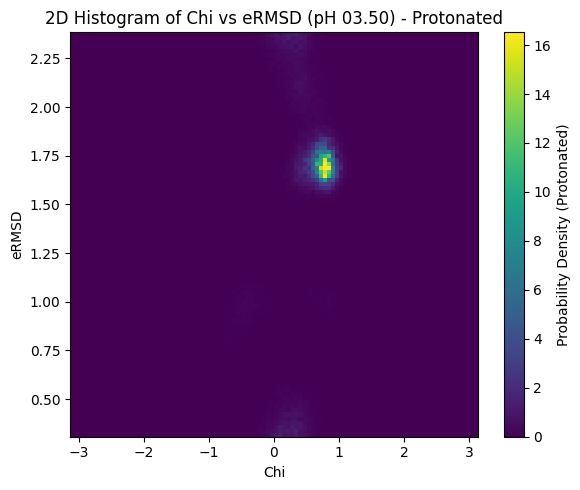

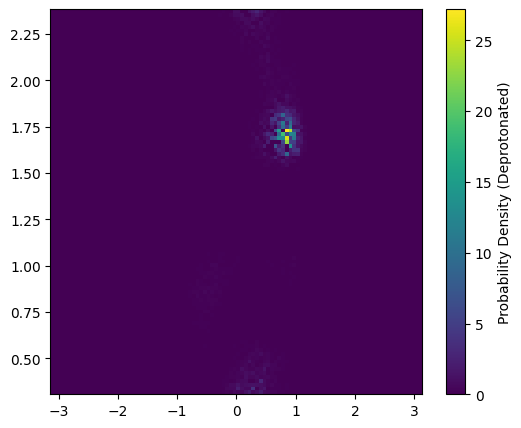

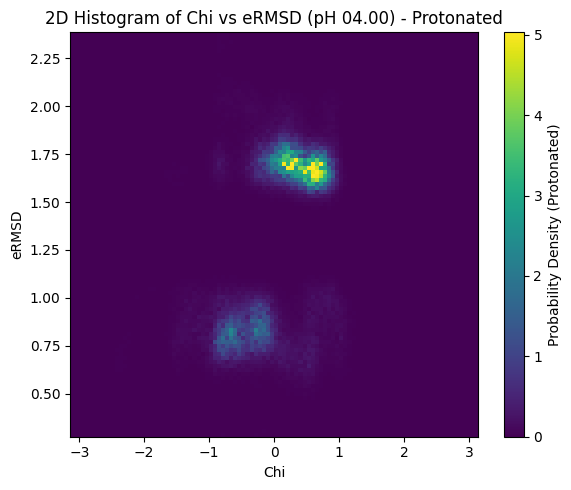

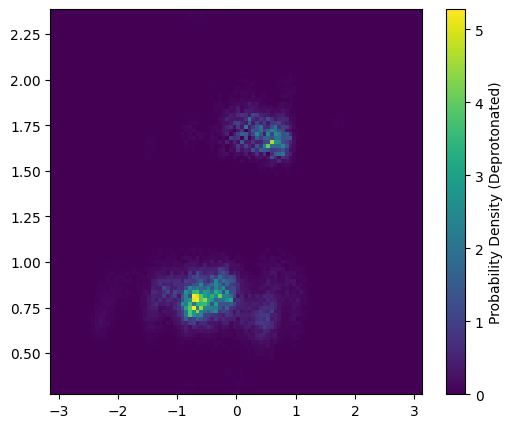

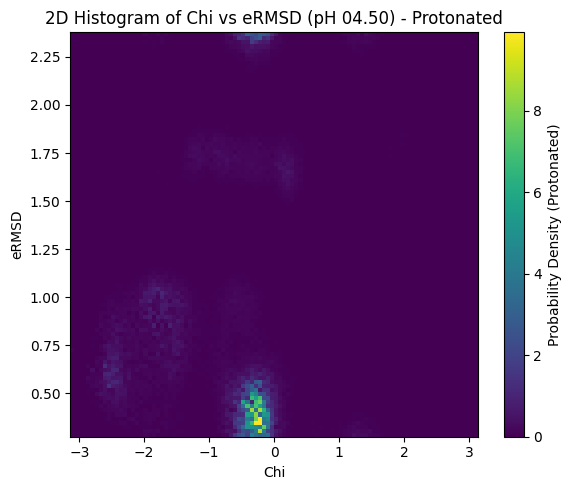

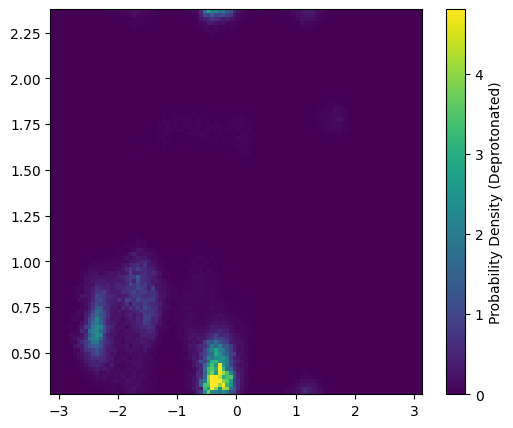

In [10]:
for pH in ["03.50","04.00","04.50"]:
    data = np.loadtxt(f"COLVAR_REWEIGHT_{pH}_weighted",comments="#",skiprows=1)
    chi = data[:,1]
    ermsd = data[:,2]
    weights = data[:,4]
    
    prot = np.loadtxt(f"A5mer_pH{pH}.occ")
    
    mask = prot.astype(bool)
    chi_p = chi[mask]
    chi_d = chi[~mask]
    ermsd_p = ermsd[mask]
    ermsd_d = ermsd[~mask]
    # Re normalize weights
    weights_p = weights[mask]
    weights_p /= np.sum(weights_p)
    
    # Re normalize
    weights_d = weights[~mask]
    weights_d /= np.sum(weights_d)

    # Create 2D histogram
    bins = 100
    hist_p, xedges, yedges = np.histogram2d(chi_p, ermsd_p, bins=bins, weights=weights_p, density=True)
    hist_d , xedges, yedges = np.histogram2d(chi_d, ermsd_d, bins=bins, weights=weights_d, density=True)
    
    # Compute the centers of the bins
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(xcenters, ycenters, indexing='ij') 
    Z_p = hist_p.T
    Z_d = hist_d.T
    
    # Plot the 2D histogram using pcolormesh
    fig, ax = plt.subplots(figsize=(6, 5))
    pcm = ax.pcolormesh(X, Y, Z_p, cmap='viridis', shading='auto', norm=plt.Normalize(vmin=0, vmax=np.max(Z_p)*0.8))
    cbar = plt.colorbar(pcm, ax=ax, label='Probability Density (Protonated)')
    ax.set_xlabel('Chi')
    ax.set_ylabel('eRMSD')
    ax.set_title(f'2D Histogram of Chi vs eRMSD (pH {pH}) - Protonated')
    plt.tight_layout()
    plt.show()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    pcd = ax.pcolormesh(X, Y, Z_d, cmap='viridis', shading='auto', norm=plt.Normalize(vmin=0, vmax=np.max(Z_d)*0.8))
    cbar = plt.colorbar(pcd, ax=ax, label='Probability Density (Deprotonated)')

    
    